# Image Captioning — Best ResNet50 Encoder

**Goal:** Train the strongest possible Encoder and export it for your friend to build an LSTM Decoder from scratch on top of it.

**What makes this notebook special:**
- ✅ ResNet50 with fine-tuning on `layer4` only (better than full freeze)
- ✅ Strong Data Augmentation (RandomCrop + Flip + ColorJitter)
- ✅ AdamW + ReduceLROnPlateau + Gradient Clipping
- ✅ Label Smoothing in the Loss function
- ✅ Multi-GPU (DataParallel) if more than one GPU is available
- ✅ Token Accuracy + BLEU + METEOR + ROUGE-L + CIDEr
- ✅ Encoder exported separately for your friend

```
Image → ResNet50 Encoder (this notebook) → Feature Vector [256] → Friend's LSTM Decoder
```

## 1. Install & Imports

In [1]:
# ─── Install evaluation libraries ────────────────────────────────────────────
!pip install nltk rouge-score pycocoevalcap -q

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt',   quiet=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 15.5 MB/s eta 0:00:0000:0100:01


True

In [2]:
import os, json, pickle, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import ResNet50_Weights

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

print('✅ Imports done')

✅ Imports done


## 2. Config & Device (Multi-GPU)

In [3]:
# ─── Paths ────────────────────────────────────────────────────────────────────
PREP       = Path('/kaggle/input/datasets/sarahsayed15102005/image-caption')
IMAGES_BASE= Path('/kaggle/input/datasets/sarahsayed15102005/image-caption/images/images')
SAVE_PATH  = Path('/kaggle/working/')
SAVE_PATH.mkdir(exist_ok=True)

# ─── Multi-GPU setup ─────────────────────────────────────────────────────────
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS    = torch.cuda.device_count()
USE_MULTI = N_GPUS > 1

print(f'Device      : {DEVICE}')
print(f'GPUs found  : {N_GPUS}')
print(f'Multi-GPU   : {USE_MULTI}')
if USE_MULTI:
    for i in range(N_GPUS):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

# ─── Hyperparameters ─────────────────────────────────────────────────────────
EMBED_DIM    = 256       
HIDDEN_DIM   = 512       
VOCAB_SIZE   = None     

BATCH_SIZE   = 32 * max(1, N_GPUS) 
LR           = 5e-5
NUM_EPOCHS   = 50
PATIENCE     = 7
MAX_SEQ_LEN  = 40
FINE_TUNE    = True     
DROPOUT      = 0.3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
GRAD_CLIP    = 1.0

print(f'\nBatch size  : {BATCH_SIZE} (per step, across all GPUs)')
print(f'Learning rate: {LR}')
print(f'Embed dim   : {EMBED_DIM}')

Device      : cuda
GPUs found  : 2
Multi-GPU   : True
  GPU 0: Tesla T4
  GPU 1: Tesla T4

Batch size  : 64 (per step, across all GPUs)
Learning rate: 5e-05
Embed dim   : 256


## 3. Vocabulary & Data

In [4]:
# ─── Load Vocabulary ─────────────────────────────────────────────────────────
with open(PREP / 'vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

word2idx   = vocab['word2idx']
idx2word   = vocab['idx2word']
VOCAB_SIZE = vocab['vocab_size']
PAD_IDX    = vocab['pad_idx']    # 0
START_IDX  = vocab['start_idx']  # 1
END_IDX    = vocab['end_idx']    # 2

# ─── Load config ─────────────────────────────────────────────────────────────
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

# ─── Load DataFrames ──────────────────────────────────────────────────────────
train_df = pd.read_csv(PREP / 'split_train.csv')
val_df   = pd.read_csv(PREP / 'split_val.csv')
test_df  = pd.read_csv(PREP / 'split_test.csv')

for df in [train_df, val_df, test_df]:
    df['tokens'] = df['tokens'].apply(eval)

print(f'Vocab size : {VOCAB_SIZE}')
print(f'Train      : {len(train_df):,}')
print(f'Val        : {len(val_df):,}')
print(f'Test       : {len(test_df):,}')

Vocab size : 4207
Train      : 10,984
Val        : 1,373
Test       : 1,374


## 4. Dataset & DataLoader

In [5]:
# ─── Transforms ──────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),                                     
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),                
    transforms.RandomGrayscale(p=0.05),                              
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])


class HouzzDataset(Dataset):
   

    def __init__(self, df, images_base: Path, transform=None,
                 max_seq_len: int = MAX_SEQ_LEN):
        self.df          = df.reset_index(drop=True)
        self.images_base = images_base
        self.transform   = transform
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Image ──────────────────────────────────────────────────────────
        # local_path : 'images/kitchen/img.jpg'  →  
        img_name  = '/'.join(row['local_path'].split('/')[1:])
        img_path  = self.images_base / img_name
        image     = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # ── Caption → tensor ───────────────────────────────────────────────
        tokens  = row['tokens'][:self.max_seq_len - 2]   
        caption = torch.tensor(
            [START_IDX] + tokens + [END_IDX],
            dtype=torch.long
        )
        return image, caption


def collate_fn(batch):
    images, captions = zip(*batch)
    images   = torch.stack(images, 0)
    captions = pad_sequence(captions, batch_first=True,
                            padding_value=PAD_IDX)
    return images, captions


# ─── Build loaders ───────────────────────────────────────────────────────────
NUM_WORKERS = min(4 * max(1, N_GPUS), os.cpu_count() or 4)

train_ds = HouzzDataset(train_df, IMAGES_BASE, train_transform)
val_ds   = HouzzDataset(val_df,   IMAGES_BASE, val_transform)
test_ds  = HouzzDataset(test_df,  IMAGES_BASE, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_fn)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print(f'Workers       : {NUM_WORKERS}')

Train batches : 172
Val batches   : 22
Test batches  : 22
Workers       : 4


## 5. Model Architecture

```
EncoderResNet50:
  ResNet50 (frozen except layer4)  →  2048
  Projection Head:  2048 → 1024 → ReLU → Dropout → 256 → LayerNorm

DecoderGRU (just test —Duha replace to  LSTM):
  Embedding(vocab, 256) → GRU(256→512, 2 layers) → Linear(512→vocab)
```

In [6]:
class EncoderResNet50(nn.Module):
    

    def __init__(self, embed_dim: int = EMBED_DIM, fine_tune: bool = FINE_TUNE,
                 dropout: float = DROPOUT):
        super().__init__()

        # ── Backbone ───────────────────────────────────────────────────────
        backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        for p in backbone.parameters():
            p.requires_grad = False

        if fine_tune:
            for p in backbone.layer4.parameters():
                p.requires_grad = True

        in_features   = backbone.fc.in_features   
        backbone.fc   = nn.Identity()            
        self.backbone = backbone

        # ── Projection head ────────────────────────────────────────────────
        # 2048 → 1024 → ReLU → Dropout → embed_dim → LayerNorm
        self.projection = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(1024, embed_dim),
            nn.LayerNorm(embed_dim),              
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.backbone(images)          # (B, 2048)
        return self.projection(features)          # (B, embed_dim)


print('✅ EncoderResNet50 defined')

✅ EncoderResNet50 defined


In [7]:
#gru is just test for training , duha replace to lstm
class DecoderGRU(nn.Module):


    def __init__(self, vocab_size: int, embed_dim: int = EMBED_DIM,
                 hidden_dim: int = HIDDEN_DIM, num_layers: int = 2,
                 dropout: float = DROPOUT):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.hidden_proj = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        self.fc_out = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, vocab_size),
        )
        self.num_layers = num_layers

    def forward(self, features: torch.Tensor,
                captions: torch.Tensor) -> torch.Tensor:
        # features: (B, embed_dim)   captions: (B, T)
        h0 = self.hidden_proj(features)                      # (B, hidden)
        h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)  # (layers, B, hidden)

        embeds     = self.embed(captions[:, :-1])            # (B, T-1, embed)
        out, _     = self.gru(embeds, h0)                    # (B, T-1, hidden)
        logits     = self.fc_out(out)                        # (B, T-1, vocab)
        return logits


print('✅ DecoderGRU defined')

✅ DecoderGRU defined


In [8]:
# ─── Build models ────────────────────────────────────────────────────────────
encoder = EncoderResNet50(embed_dim=EMBED_DIM, fine_tune=FINE_TUNE,
                          dropout=DROPOUT)
decoder = DecoderGRU(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                     hidden_dim=HIDDEN_DIM, num_layers=2, dropout=DROPOUT)

# ─── Wrap with DataParallel for multi-GPU ────────────────────────────────────
if USE_MULTI:
    encoder = nn.DataParallel(encoder)
    decoder = nn.DataParallel(decoder)
    print(f'🚀 Using DataParallel on {N_GPUS} GPUs')

encoder = encoder.to(DEVICE)
decoder = decoder.to(DEVICE)

# ─── Parameter count ─────────────────────────────────────────────────────────
enc_total     = sum(p.numel() for p in encoder.parameters())
enc_trainable = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
dec_total     = sum(p.numel() for p in decoder.parameters())

print(f'Encoder total params    : {enc_total:,}')
print(f'Encoder trainable params: {enc_trainable:,}')
print(f'Decoder total params    : {dec_total:,}')
print(f'Total trainable         : {enc_trainable + dec_total:,}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s] 


🚀 Using DataParallel on 2 GPUs
Encoder total params    : 25,869,120
Encoder trainable params: 17,325,824
Decoder total params    : 6,125,423
Total trainable         : 23,451,247


## 6. Loss, Optimizer & Scheduler

In [10]:
# ─── Loss ─────────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX,
    label_smoothing=LABEL_SMOOTH
)

# ─── Optimizer ────────────────────────────────────────────────────────────────
trainable_params = (
    list(filter(lambda p: p.requires_grad, encoder.parameters())) +
    list(decoder.parameters())
)
optimizer = optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)

# ─── Scheduler ────────────────────────────────────────────────────────────────
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5,
    
)

print('✅ Criterion, Optimizer, Scheduler ready')
print(f'   Trainable param groups: {len(trainable_params):,} tensors')

✅ Criterion, Optimizer, Scheduler ready
   Trainable param groups: 49 tensors


## 7. Helpers: Token Accuracy & Smoke Test

In [11]:
def token_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    """
    Computes per-token accuracy, ignoring PAD positions.
    logits : (B, T, vocab_size)
    targets: (B, T)
    """
    preds   = logits.argmax(dim=-1)          # (B, T)
    mask    = targets != PAD_IDX
    correct = (preds == targets) & mask
    return correct.sum().item() / mask.sum().item()


# ─── Smoke test ──────────────────────────────────────────────────────────────
encoder.eval(); decoder.eval()
with torch.no_grad():
    dummy_imgs = torch.randn(4, 3, 224, 224).to(DEVICE)
    dummy_caps = torch.randint(3, VOCAB_SIZE, (4, MAX_SEQ_LEN)).to(DEVICE)
    dummy_caps[:, 0] = START_IDX

    feats  = encoder(dummy_imgs)
    logits = decoder(feats, dummy_caps)
    loss   = criterion(logits.reshape(-1, VOCAB_SIZE),
                       dummy_caps[:, 1:].reshape(-1))

print(f'Encoder output : {feats.shape}')     # (4, 256)
print(f'Decoder output : {logits.shape}')    # (4, T-1, vocab)
print(f'Smoke test loss: {loss.item():.4f}')
print('✅ Shapes are correct')

Encoder output : torch.Size([4, 256])
Decoder output : torch.Size([4, 39, 4207])
Smoke test loss: 8.3394
✅ Shapes are correct


## 8. Training Loop

In [12]:
def run_epoch(loader, is_train: bool = True):
    """
    """
    encoder.train(is_train)
    decoder.train(is_train)

    total_loss    = 0.0
    total_correct = 0
    total_tokens  = 0

    ctx  = torch.enable_grad() if is_train else torch.no_grad()
    desc = 'Train' if is_train else 'Val  '

    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False)
        for images, captions in pbar:
            images   = images.to(DEVICE, non_blocking=True)
            captions = captions.to(DEVICE, non_blocking=True)

            features = encoder(images)              # (B, 256)
            logits   = decoder(features, captions)  # (B, T-1, vocab)
            targets  = captions[:, 1:]              

            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                targets.reshape(-1)
            )

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                # Gradient clipping → no exploding gradients
                nn.utils.clip_grad_norm_(trainable_params, max_norm=GRAD_CLIP)
                optimizer.step()

            # ── Accuracy ─────────────────────────────────────────────────
            preds   = logits.argmax(dim=-1)
            mask    = targets != PAD_IDX
            correct = ((preds == targets) & mask).sum().item()
            tokens  = mask.sum().item()

            total_loss    += loss.item()
            total_correct += correct
            total_tokens  += tokens

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc' : f'{correct/max(tokens,1):.3f}'
            })

    avg_loss = total_loss    / len(loader)
    avg_acc  = total_correct / max(total_tokens, 1)
    return avg_loss, avg_acc


# ─── Main Training Loop ──────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0

print('🚀 Training started ...\n')
for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    train_loss, train_acc = run_epoch(train_loader, is_train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   is_train=False)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    flag    = ''

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            'epoch'          : epoch + 1,
            'encoder'        : (encoder.module if USE_MULTI else encoder).state_dict(),
            'decoder'        : (decoder.module if USE_MULTI else decoder).state_dict(),
            'optimizer'      : optimizer.state_dict(),
            'best_val_loss'  : best_val_loss,
            'vocab'          : vocab,
            'embed_dim'      : EMBED_DIM,
        }, SAVE_PATH / 'best_model.pth')
        flag = ' ✅ saved'
    else:
        patience_counter += 1

    print(f'Epoch [{epoch+1:>2}/{NUM_EPOCHS}]  '
          f'train loss={train_loss:.4f} acc={train_acc:.4f}  '
          f'val loss={val_loss:.4f} acc={val_acc:.4f}  '
          f'({elapsed:.0f}s){flag}')

    if patience_counter >= PATIENCE:
        print(f'\n⏹  Early stopping — val loss no optimize {PATIENCE} epochs')
        break

print(f'\n✅ Best val loss: {best_val_loss:.4f}')

with open(SAVE_PATH / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

🚀 Training started ...



Train:   0%|          | 0/172 [00:00<?, ?it/s]

Val  :   0%|          | 0/22 [00:00<?, ?it/s]

Epoch [ 1/50]  train loss=6.4737 acc=0.1145  val loss=5.4412 acc=0.1559  (65s) ✅ saved


Train:   0%|          | 0/172 [00:00<?, ?it/s]

...

Epoch [36/50]  train loss=3.2798 acc=0.5351  val loss=3.3747 acc=0.5259  (64s) ✅ saved


Train:   0%|          | 0/172 [00:00<?, ?it/s]

Val  :   0%|          | 0/22 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c69b3daba60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

RuntimeError: DataLoader worker (pid(s) 31541, 31544, 31551, 31552) exited unexpectedly

## 9. Training History Plot

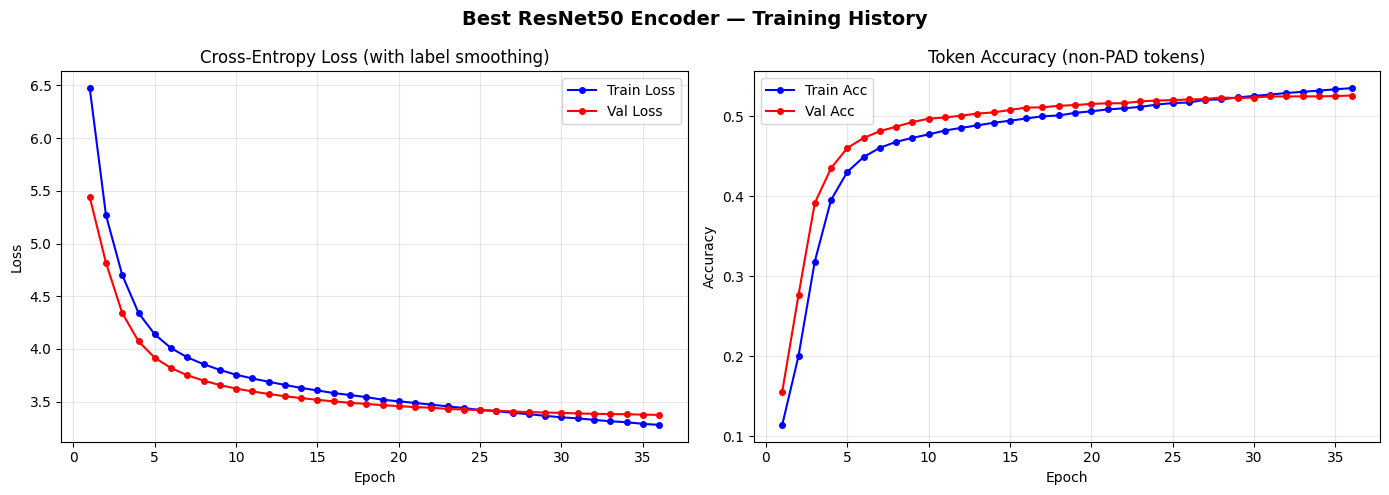

✅ Plot saved


In [13]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Best ResNet50 Encoder — Training History', fontsize=14, fontweight='bold')

axes[0].plot(epochs_ran, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_ran, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].set_title('Cross-Entropy Loss (with label smoothing)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_ran, history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
axes[1].set_title('Token Accuracy (non-PAD tokens)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_PATH / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved')

## 10. Load Best & Generate Captions (Greedy)

In [14]:
# ─── Load best checkpoint ─────────────────────────────────────────────────────
checkpoint = torch.load(SAVE_PATH / 'best_model.pth', map_location=DEVICE)

_enc = encoder.module if USE_MULTI else encoder
_dec = decoder.module if USE_MULTI else decoder
_enc.load_state_dict(checkpoint['encoder'])
_dec.load_state_dict(checkpoint['decoder'])

encoder.eval(); decoder.eval()
print(f'✅ Best model loaded (epoch {checkpoint["epoch"]})')


def generate_caption(image_path: str, max_len: int = MAX_SEQ_LEN) -> str:
   
    _enc = encoder.module if USE_MULTI else encoder
    _dec = decoder.module if USE_MULTI else decoder
    _enc.eval(); _dec.eval()

    image = Image.open(image_path).convert('RGB')
    image = val_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        feature = _enc(image)                              # (1, 256)
        h = _dec.hidden_proj(feature).unsqueeze(0)         # (1, 1, hidden)
        h = h.repeat(_dec.gru.num_layers, 1, 1)           # (layers, 1, hidden)

        token = torch.tensor([[START_IDX]], device=DEVICE)
        words = []

        for _ in range(max_len):
            embed       = _dec.embed(token)                # (1, 1, 256)
            out, h      = _dec.gru(embed, h)               # (1, 1, hidden)
            logit       = _dec.fc_out(out.squeeze(1))      # (1, vocab)
            token       = logit.argmax(dim=-1).unsqueeze(1)
            word_id     = token.item()

            if word_id == END_IDX:
                break
            if word_id not in (PAD_IDX, START_IDX):
                words.append(idx2word[word_id])

    return ' '.join(words)


# ─── Demo ────────────────────────────────────────────────────────────────────
print('\n=== Sample Captions ===')
for _, row in val_df.sample(5, random_state=42).iterrows():
    img_name = '/'.join(row['local_path'].split('/')[1:])
    img_path = str(IMAGES_BASE / img_name)
    pred     = generate_caption(img_path)
    print(f'[{row["room_type"]}]')
    print(f'  Real : {row["caption"][:120]}')
    print(f'  Pred : {pred}\n')

✅ Best model loaded (epoch 36)

=== Sample Captions ===
[pool]
  Real : side yard rectangular natural pool
  Pred : backyard concrete and rectangular lap pool

[kitchen]
  Real : built by old hampshire designs inc john w hession l shaped light wood floor and beige floor open concept kitchen with an
  Pred : l shaped medium tone wood floor and brown floor kitchen with a sink shaker cabinets white cabinets white backsplash stainless steel appliances an island and white countertops

[bedroom]
  Real : accented with tasteful geometric lines this makeup vanity lends a glamorous flair that blends well with any decor this v
  Pred : freestanding desk light wood floor and beige floor home office with white walls

[kitchen]
  Real : international award winner nkba design competition best overall kitchen tida international usa kitchen of the year best 
  Pred : l shaped medium tone wood floor and brown floor kitchen with a sink shaker cabinets white cabinets white backsplash stainless steel appl

## 11. Full Evaluation: BLEU + METEOR + ROUGE-L + CIDEr

In [15]:
# ─── Generate all test captions ──────────────────────────────────────────────
predictions = []
references  = []

for idx in tqdm(range(len(test_df)), desc='Generating captions'):
    row      = test_df.iloc[idx]
    img_name = '/'.join(row['local_path'].split('/')[1:])
    img_path = str(IMAGES_BASE / img_name)
    gen      = generate_caption(img_path, max_len=MAX_SEQ_LEN)
    predictions.append(gen)
    references.append(row['caption'])

print(f'\n✅ Generated {len(predictions)} captions')

Generating captions:   0%|          | 0/1374 [00:00<?, ?it/s]


✅ Generated 1374 captions


In [16]:
from nltk.translate.bleu_score  import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score                import rouge_scorer

hyps = [p.split() for p in predictions]
refs = [[r.split()] for r in references]

smooth = SmoothingFunction().method1
bleu1  = corpus_bleu(refs, hyps, weights=(1.0, 0, 0, 0),   smoothing_function=smooth)
bleu4  = corpus_bleu(refs, hyps, weights=(0.25,)*4,         smoothing_function=smooth)

meteor = sum(meteor_score(r, h) for r, h in zip(refs, hyps)) / len(hyps)

rouge  = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_l = sum(
    rouge.score(ref, hyp)['rougeL'].fmeasure
    for hyp, ref in zip(predictions, references)
) / len(predictions)

# ── CIDEr ──────────────────────────────────────────────────────────────────
cider = None
try:
    from pycocoevalcap.cider.cider import Cider
    gts = {i: [references[i]]  for i in range(len(references))}
    res = {i: [predictions[i]] for i in range(len(predictions))}
    cider, _ = Cider().compute_score(gts, res)
except Exception as e:
    print(f'⚠️  CIDEr failed: {e}')

# ── Room-type accuracy ─────────────────────────────────────────────────────
room_keywords = {
    'bathroom':    ['bathroom', 'bath', 'shower', 'toilet', 'vanity'],
    'bedroom':     ['bedroom', 'bed', 'master'],
    'home-office': ['office', 'desk', 'study'],
    'kitchen':     ['kitchen', 'pantry'],
    'living-room': ['living', 'lounge'],
    'pool':        ['pool', 'hot tub', 'spa'],
}
correct = sum(
    any(kw in predictions[i].lower() for kw in room_keywords.get(test_df.iloc[i]['room_type'], []))
    for i in range(len(test_df))
)
room_acc = correct / len(test_df) * 100

print('\n' + '='*45)
print('         EVALUATION RESULTS')
print('='*45)
print(f'  BLEU-1    : {bleu1:.4f}')
print(f'  BLEU-4    : {bleu4:.4f}')
print(f'  METEOR    : {meteor:.4f}')
print(f'  ROUGE-L   : {rouge_l:.4f}')
print(f'  CIDEr     : {cider:.4f}' if cider is not None else '  CIDEr     : n/a')
print(f'  Room Acc  : {room_acc:.1f}%')
print('='*45)


         EVALUATION RESULTS
  BLEU-1    : 0.3500
  BLEU-4    : 0.1634
  METEOR    : 0.3518
  ROUGE-L   : 0.3611
  CIDEr     : 0.8742
  Room Acc  : 87.8%


In [17]:
# ─── Save all metrics & predictions ─────────────────────────────────────────
metrics = {
    'model'         : 'Best ResNet50 (layer4 fine-tuned) + GRU',
    'best_val_loss' : round(best_val_loss, 4),
    'test_samples'  : len(predictions),
    'BLEU-1'        : round(bleu1,    4),
    'BLEU-4'        : round(bleu4,    4),
    'METEOR'        : round(meteor,   4),
    'ROUGE-L'       : round(rouge_l,  4),
    'CIDEr'         : round(cider,    4) if cider is not None else None,
    'Room_Acc_%'    : round(room_acc, 2),
    'hyperparams'   : {
        'EMBED_DIM'    : EMBED_DIM,
        'HIDDEN_DIM'   : HIDDEN_DIM,
        'BATCH_SIZE'   : BATCH_SIZE,
        'LR'           : LR,
        'DROPOUT'      : DROPOUT,
        'LABEL_SMOOTH' : LABEL_SMOOTH,
        'FINE_TUNE'    : FINE_TUNE,
        'N_GPUS'       : N_GPUS,
    },
}

with open(SAVE_PATH / 'eval_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

results_df = test_df[['local_path', 'room_type', 'caption']].copy()
results_df = results_df.rename(columns={'caption': 'true_caption'})
results_df['generated'] = predictions
results_df.to_csv(SAVE_PATH / 'test_predictions.csv', index=False)

print(json.dumps(metrics, indent=2))
print('\n✅ Metrics saved → eval_metrics.json')
print('✅ Predictions saved → test_predictions.csv')

{
  "model": "Best ResNet50 (layer4 fine-tuned) + GRU",
  "best_val_loss": 3.3747,
  "test_samples": 1374,
  "BLEU-1": 0.35,
  "BLEU-4": 0.1634,
  "METEOR": 0.3518,
  "ROUGE-L": 0.3611,
  "CIDEr": 0.8742,
  "Room_Acc_%": 87.85,
  "hyperparams": {
    "EMBED_DIM": 256,
    "HIDDEN_DIM": 512,
    "BATCH_SIZE": 64,
    "LR": 5e-05,
    "DROPOUT": 0.3,
    "LABEL_SMOOTH": 0.1,
    "FINE_TUNE": true,
    "N_GPUS": 2
  }
}

✅ Metrics saved → eval_metrics.json
✅ Predictions saved → test_predictions.csv


In [19]:
room_keywords = {
    'bathroom':    ['bathroom', 'bath', 'shower', 'toilet', 'vanity'],
    'bedroom':     ['bedroom', 'bed', 'master'],
    'home-office': ['office', 'desk', 'study'],
    'kitchen':     ['kitchen', 'pantry'],
    'living-room': ['living', 'lounge'],
    'pool':        ['pool', 'hot tub', 'spa'],
}

# ── Per-room breakdown ────────────────────────────────────────────────────────
room_correct = {r: 0 for r in room_keywords}
room_total   = {r: 0 for r in room_keywords}

for idx in range(len(test_df)):
    room      = test_df.iloc[idx]['room_type']
    generated = predictions[idx].lower()
    room_total[room] += 1
    if any(kw in generated for kw in room_keywords.get(room, [])):
        room_correct[room] += 1

overall = sum(room_correct.values()) / len(test_df) * 100

print('='*40)
print('     ROOM-TYPE ACCURACY')
print('='*40)
for room in room_keywords:
    total = room_total[room]
    if total == 0:
        continue
    acc = room_correct[room] / total * 100
    bar = '█' * int(acc // 5)
    print(f'  {room:<12} {acc:5.1f}%  {bar}')
print('─'*40)
print(f'  {"Overall":<12} {overall:5.1f}%')
print('='*40)

     ROOM-TYPE ACCURACY
  bathroom      92.4%  ██████████████████
  bedroom       87.2%  █████████████████
  home-office   78.2%  ███████████████
  kitchen       92.2%  ██████████████████
  living-room   85.5%  █████████████████
  pool          91.7%  ██████████████████
────────────────────────────────────────
  Overall       87.8%


## 12. Export Encoder for Your Friend's LSTM

Complete this cell to build lstm from scratch

```python
# to duha use lstm 
ckpt    = torch.load('encoder_for_lstm.pth')
encoder = EncoderResNet50(embed_dim=ckpt['embed_dim'])
encoder.load_state_dict(ckpt['encoder_state_dict'])
encoder.eval()
# feature = encoder(image)  →  (B, 256)
```

In [21]:
# ─── Export Encoder only ──────────────────────────────────────────────────────
_enc_to_save = encoder.module if USE_MULTI else encoder

torch.save({
    # ── Encoder weights ──────────────────────────────────────────────────
    'encoder_state_dict' : _enc_to_save.state_dict(),

    # ── Architecture info (u need know this nums) ───────────────
    'embed_dim'          : EMBED_DIM,        # 256  — output size of encoder
    'fine_tune'          : FINE_TUNE,
    'dropout'            : DROPOUT,

    # ── Vocab info (same  Embedding and FC) ─────────
    'vocab_size'         : VOCAB_SIZE,
    'pad_idx'            : PAD_IDX,
    'start_idx'          : START_IDX,
    'end_idx'            : END_IDX,
    'word2idx'           : word2idx,
    'idx2word'           : idx2word,

    # ── Training info ──────────────────────────────────────────────────
    'best_val_loss'      : best_val_loss,
    'img_mean'           : IMG_MEAN,         #   duha need do same  normalization
    'img_std'            : IMG_STD,
    'max_seq_len'        : MAX_SEQ_LEN,

}, SAVE_PATH / 'encoder_for_lstm.pth')

print('✅ Encoder exported → encoder_for_lstm.pth')
print()
print('📋 What\'s inside the checkpoint:')
print('   encoder_state_dict  —  weights full')
print('   embed_dim = 256     — output  encoder (= input  LSTM)')
print('   vocab_size, pad/start/end idx')
print('   word2idx, idx2word  —  vocab full')
print('   img_mean, img_std   — make do on img before inputs')
print('   max_seq_len = 40')

✅ Encoder exported → encoder_for_lstm.pth

📋 What's inside the checkpoint:
   encoder_state_dict  —  weights full
   embed_dim = 256     — output  encoder (= input  LSTM)
   vocab_size, pad/start/end idx
   word2idx, idx2word  —  vocab full
   img_mean, img_std   — make do on img before inputs
   max_seq_len = 40


## 13. Verify Export (Optional)



In [22]:
# ─── Reload from scratch and verify ─────────────────────────────────────────
ckpt = torch.load(SAVE_PATH / 'encoder_for_lstm.pth', map_location='cpu')

verify_enc = EncoderResNet50(
    embed_dim = ckpt['embed_dim'],
    fine_tune = False,           # fine_tune=False in inference
    dropout   = 0.0,
)
verify_enc.load_state_dict(ckpt['encoder_state_dict'])
verify_enc.eval()

with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224)
    out   = verify_enc(dummy)

print(f'✅ Encoder reload OK')
print(f'   Input  shape: {dummy.shape}')
print(f'   Output shape: {out.shape}  (should be [2, {EMBED_DIM}])')
print(f'   Vocab size  : {ckpt["vocab_size"]}')
print(f'   embed_dim   : {ckpt["embed_dim"]}')
print(f'   img_mean    : {ckpt["img_mean"]}')
print(f'   max_seq_len : {ckpt["max_seq_len"]}')
print()
print('done , u can send')
print('   u need class EncoderResNet50 just (without decoder)')

✅ Encoder reload OK
   Input  shape: torch.Size([2, 3, 224, 224])
   Output shape: torch.Size([2, 256])  (should be [2, 256])
   Vocab size  : 4207
   embed_dim   : 256
   img_mean    : [0.485, 0.456, 0.406]
   max_seq_len : 40

done , u can send
   u need class EncoderResNet50 just (without decoder)


---

## notes for build LSTM

```python
# ─── ur code must begin like this ───────────────────────────────────────────

ckpt    = torch.load('encoder_for_lstm.pth')
encoder = EncoderResNet50(embed_dim=ckpt['embed_dim'], fine_tune=False, dropout=0.0)
encoder.load_state_dict(ckpt['encoder_state_dict'])
encoder.eval()

# freeze for encoder while train LSTM (optional but faster)
for p in encoder.parameters():
    p.requires_grad = False

# build LSTM decoder:
class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, num_layers=1):
        super().__init__()
        self.embed     = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.hidden_fc = nn.Linear(embed_dim, hidden_dim)   # encoder → h0
        self.cell_fc   = nn.Linear(embed_dim, hidden_dim)   # encoder → c0
        self.fc_out    = nn.Linear(hidden_dim, vocab_size)

    def forward(self, features, captions):
        h0  = self.hidden_fc(features).unsqueeze(0)  # (1, B, hidden)
        c0  = self.cell_fc(features).unsqueeze(0)
        emb = self.embed(captions[:, :-1])
        out, _ = self.lstm(emb, (h0, c0))
        return self.fc_out(out)

# img_mean و img_std from checkpoint me:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=ckpt['img_mean'], std=ckpt['img_std']),
])
```